<a href="https://colab.research.google.com/github/tungduong2106/PracticeML/blob/main/Practice3_fix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

dataset = type('obj', (object,), {'data': data, 'target': target})()

print ("So chieu du lieu input: ",dataset.data.shape)
print ("So chieu du lieu target: ",dataset.target.shape)
print()
print("5 mau du lieu dau tien:")
print("input: ",dataset.data[:5])
print("target: ",dataset.target[:5])

So chieu du lieu input:  (506, 13)
So chieu du lieu target:  (506,)

5 mau du lieu dau tien:
input:  [[6.3200e-03 1.8000e+01 2.3100e+00 0.0000e+00 5.3800e-01 6.5750e+00
  6.5200e+01 4.0900e+00 1.0000e+00 2.9600e+02 1.5300e+01 3.9690e+02
  4.9800e+00]
 [2.7310e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 6.4210e+00
  7.8900e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 3.9690e+02
  9.1400e+00]
 [2.7290e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 7.1850e+00
  6.1100e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 3.9283e+02
  4.0300e+00]
 [3.2370e-02 0.0000e+00 2.1800e+00 0.0000e+00 4.5800e-01 6.9980e+00
  4.5800e+01 6.0622e+00 3.0000e+00 2.2200e+02 1.8700e+01 3.9463e+02
  2.9400e+00]
 [6.9050e-02 0.0000e+00 2.1800e+00 0.0000e+00 4.5800e-01 7.1470e+00
  5.4200e+01 6.0622e+00 3.0000e+00 2.2200e+02 1.8700e+01 3.9690e+02
  5.3300e+00]]
target:  [24.  21.6 34.7 33.4 36.2]


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_197/73100996.py:2: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [3]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [4]:
X_train,X_test,y_train,y_test = train_test_split(dataset.data,dataset.target,test_size = 0.2, random_state= 42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
# Xay dung mo hinh bang thu vien
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [6]:
# Xay dung mo hinh bang ham Linear tu viet
def add_bias(X):
  return np.c_[np.ones((X.shape[0],1)),X]
def train_linear (X,y):
  X = add_bias(X)
  return np.linalg.pinv(X.T @ X) @ X.T @y

In [7]:
# Ham du doan linear tu viet
def predict_linear(X,w):
  return add_bias(X) @ w

In [8]:
# Xay dung ham test bang ham linear tu viet
def test_linear (X,y,w):
  y_pred = predict_linear(X,w)
  mse = np.sqrt(mean_squared_error(y,y_pred))
  r2 = r2_score(y,y_pred)
  print("RMSE linear tự viết: ", mse)
  print("r2 linear tự viết: ", r2)

<function matplotlib.pyplot.show(close=None, block=None)>

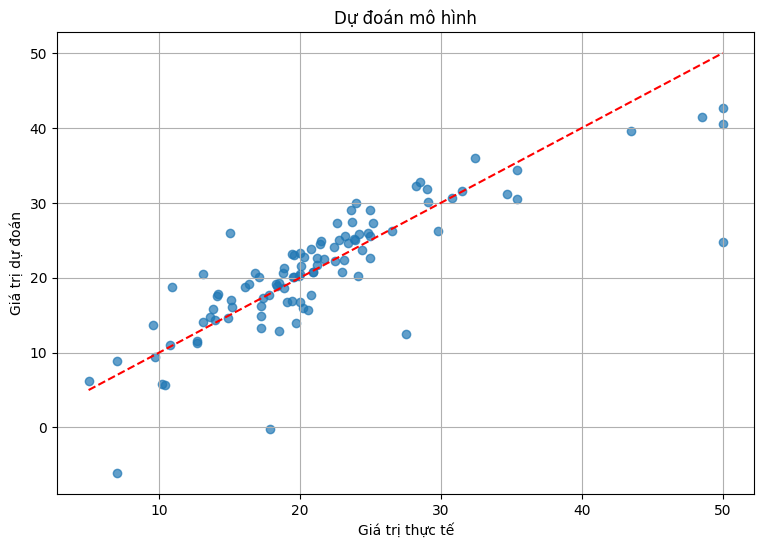

In [9]:
# Huan luyen va du doan mo hinh bang thu vien
y_pred_1 = model.predict(X_test)
# Ve do thi mo hinh
plt.figure(figsize=(9,6))
plt.scatter(y_test,y_pred_1,alpha = 0.7)
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)], 'r--')
plt.xlabel("Giá trị thực tế")
plt.ylabel("Giá trị dự đoán")
plt.title('Dự đoán mô hình')
plt.grid(True)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

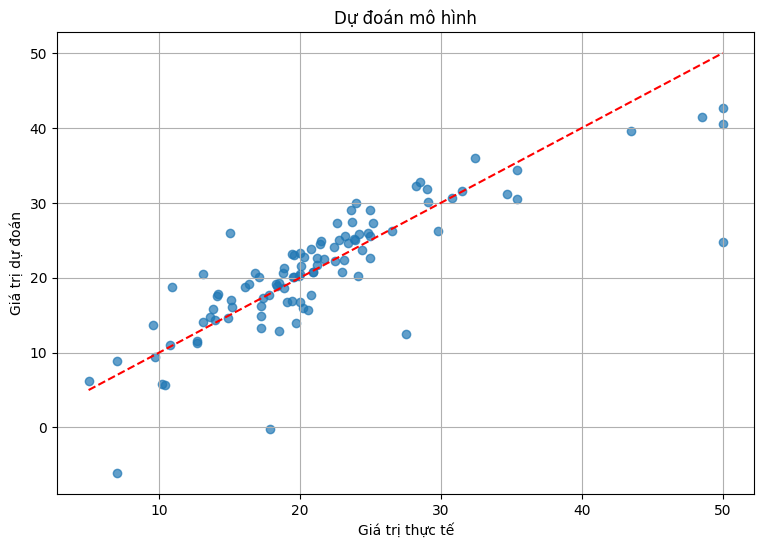

In [10]:
# Train bang ham linear tu viet
w = train_linear(X_train,y_train)
y_pred_2 = predict_linear(X_test,w)
# Ve do thi
plt.figure(figsize=(9,6))
plt.scatter(y_test,y_pred_2,alpha = 0.7)
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)], 'r--')
plt.xlabel("Giá trị thực tế")
plt.ylabel("Giá trị dự đoán")
plt.title('Dự đoán mô hình')
plt.grid(True)
plt.show

In [11]:
# Danh gia mo hinh bang thu vien
mse_1 = np.sqrt(mean_squared_error(y_test,y_pred_1))
r2_1 = r2_score(y_test,y_pred_1)
print("RMSE thư viện: ", mse_1)
print("r2 thư viện: ", r2_1)

RMSE thư viện:  4.928602182665336
r2 thư viện:  0.668759493535632


In [12]:
# Danh gia mo hinh linear tu viet
test_linear(X_test,y_test,w)

RMSE linear tự viết:  4.928602182665341
r2 linear tự viết:  0.6687594935356314
